In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import os

path = r"C:\Users\Мартинсон Диана\cars\data\processed\cleaned_cars.csv"
df = pd.read_csv(path)
print(f"Данные для ML: {len(df)} записей")
print(f"Колонки: {df.columns.tolist()}")

Данные для ML: 50 записей
Колонки: ['location', 'price', 'price_number', 'params', 'id', 'description', 'title', 'url', 'date', 'engine', 'mileage', 'brand', 'year', 'age']


In [3]:
ml_data = df[['brand', 'year', 'mileage', 'price']].copy()
ml_data = ml_data.dropna()

print(f"После удаления прорусков: {len(ml_data)} записей")

le = LabelEncoder()
ml_data['brand_encoded'] = le.fit_transform(ml_data['brand'])

x = ml_data[['brand_encoded', 'year', 'mileage']]
y = ml_data['price']

print(f"Фичи: {x.shape}")
print(f"Целевая переменная: {y.shape}")


После удаления прорусков: 50 записей
Фичи: (50, 3)
Целевая переменная: (50,)


In [4]:
# Обработка столбца mileage
def clean_mileage(value):
    if isinstance(value, str):
        # Удаляем "км", неразрывные пробелы и обычные пробелы
        value = value.replace('км', '').replace('\xa0', '').replace(' ', '')
        # Преобразуем в число
        try:
            return float(value)
        except:
            return None
    return value

# Применяем очистку к столбцу mileage
ml_data = df[['brand', 'year', 'mileage', 'price']].copy()
ml_data['mileage'] = ml_data['mileage'].apply(clean_mileage)

# Теперь удаляем пропуски
ml_data = ml_data.dropna()

print(f"После удаления пропусков: {len(ml_data)} записей")

# Продолжаем как раньше
le = LabelEncoder()
ml_data['brand_encoded'] = le.fit_transform(ml_data['brand'])
X = ml_data[['brand_encoded', 'year', 'mileage']]
y = ml_data['price']

print(f"Фичи: {X.shape}")
print(f"Целевая переменная: {y.shape}")

# Разделяем данные
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Тренировочная выборка: {X_train.shape}")
print(f"Тестовая выборка: {X_test.shape}")

# Теперь модель должна обучаться без ошибок
print("Обучение модели...")
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("=" * 50)
print("Результаты модели: ")
print(f"• MAE (Средняя абсолютная ошибка): {mae:,.0f} руб")
print(f"• R² Score: {r2:.3f}")
print(f"• Это значит модель объясняет {r2*100:.1f}% variance в данных")

После удаления пропусков: 50 записей
Фичи: (50, 3)
Целевая переменная: (50,)
Тренировочная выборка: (40, 3)
Тестовая выборка: (10, 3)
Обучение модели...
Результаты модели: 
• MAE (Средняя абсолютная ошибка): 256,746 руб
• R² Score: 0.811
• Это значит модель объясняет 81.1% variance в данных


Важность признаков:
         feature  importance
1           year    0.467435
2        mileage    0.370029
0  brand_encoded    0.162536


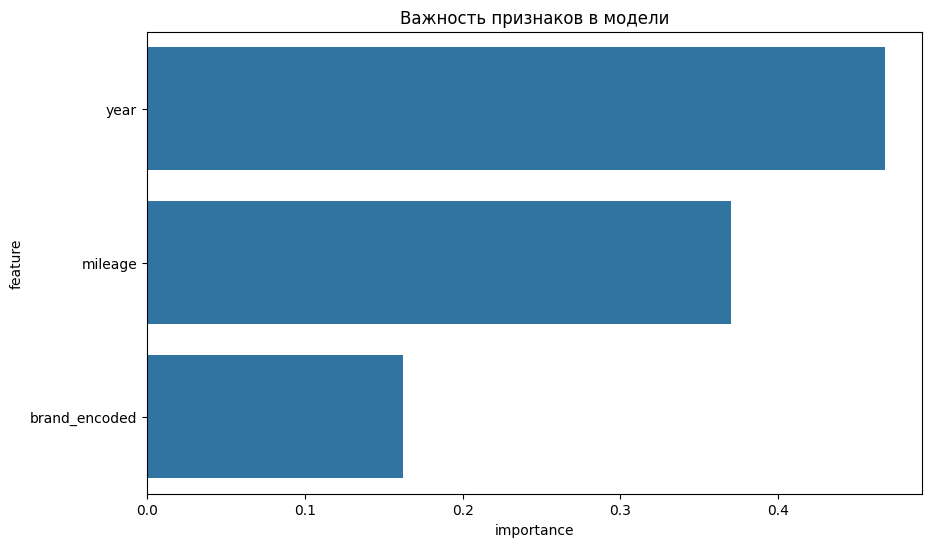

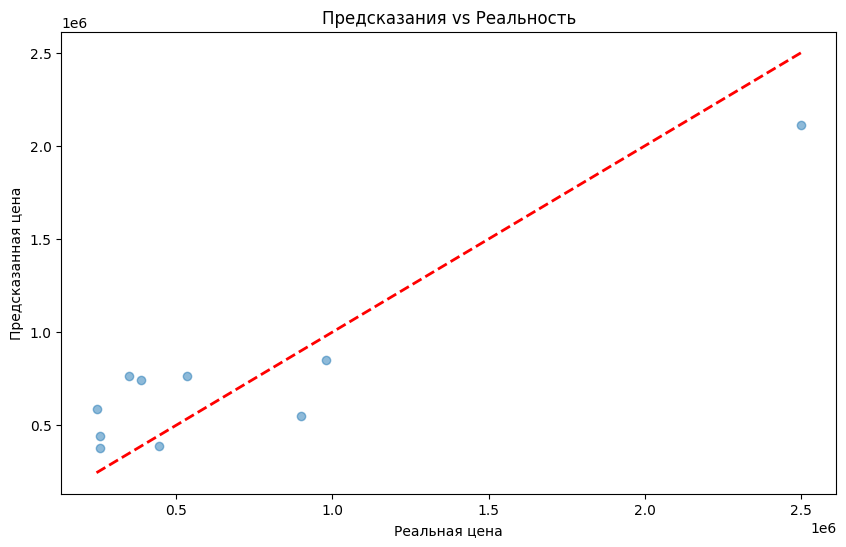

In [5]:
# Анализ важности признаков - исправленная версия
feature_importance = pd.DataFrame({
    'feature': X.columns,  # Заглавная X, и правильный синтаксис словаря
    'importance': model.feature_importances_  # feature_importances_ с 's' на конце
}).sort_values('importance', ascending=False)

print("Важность признаков:")
print(feature_importance)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature')  # data= вместо data-
plt.title('Важность признаков в модели')
plt.show()

# График предсказания vs реальность
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)  # lw вместо Lw
plt.xlabel('Реальная цена')
plt.ylabel('Предсказанная цена')
plt.title('Предсказания vs Реальность')
plt.show()

АНАЛИЗ РЫНКА АВТОМОБИЛЕЙ
В проекте проанализировано: 50 автомобилей
Средняя цена на рынке: 852 520 руб
Медианная цена: 644 500 руб
Уникальных марок: 21
Топ-5 марок: Lada, Hyundai, Ford, Kia, Opel

--------------------------------------------------
ДОПОЛНИТЕЛЬНАЯ СТАТИСТИКА:
--------------------------------------------------
Годы выпуска: от 1998 до 2024
Средний год выпуска: 2012.0
Средний пробег: 174 008 км
Медианный пробег: 176 750 км

ДИАПАЗОН ЦЕН:
Минимальная цена: 180 000 руб
Максимальная цена: 2 650 000 руб
Стандартное отклонение: 640 326 руб

ТОП-5 МАРОК (ДЕТАЛИЗАЦИЯ):
  Lada: 7 авто  средняя цена 567 000 руб
  Hyundai: 7 авто  средняя цена 746 143 руб
  Ford: 4 авто  средняя цена 584 750 руб
  Kia: 3 авто  средняя цена 1 255 000 руб
  Opel: 3 авто  средняя цена 580 000 руб

ПРОЕКТ УСПЕШНО ЗАВЕРШЕН! 🎉


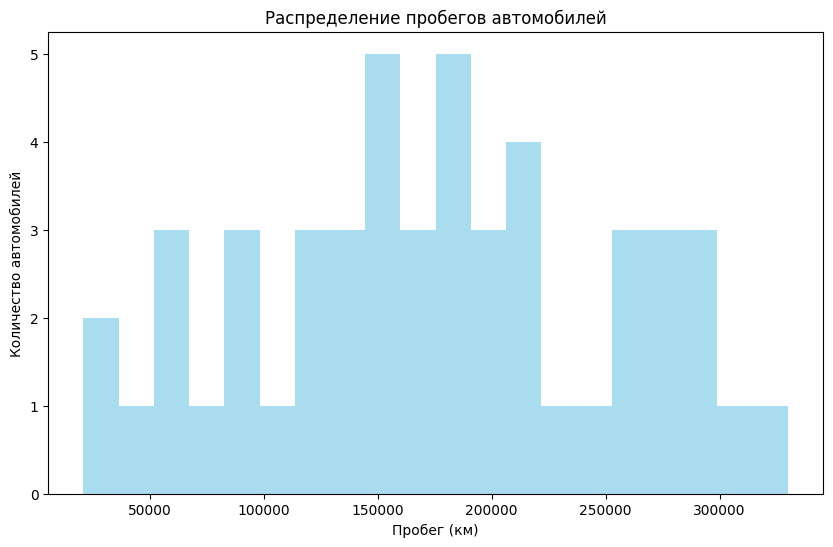

In [7]:
import pandas as pd
import numpy as np

# Загружаем данные
path = r"C:\Users\Мартинсон Диана\cars\data\processed\cleaned_cars.csv"
df = pd.read_csv(path)

# Функция для очистки пробега
def clean_mileage(mileage):
    if pd.isna(mileage):
        return np.nan
    if isinstance(mileage, (int, float)):
        return float(mileage)
    
    # Удаляем все нецифровые символы, кроме цифр
    cleaned = ''.join(filter(str.isdigit, str(mileage)))
    
    if cleaned:
        return float(cleaned)
    else:
        return np.nan

# Очищаем столбец пробега
df['mileage_cleaned'] = df['mileage'].apply(clean_mileage)

print("=" * 50)
print("АНАЛИЗ РЫНКА АВТОМОБИЛЕЙ")
print("=" * 50)
print(f"В проекте проанализировано: {len(df):,} автомобилей".replace(',', ' '))
print(f"Средняя цена на рынке: {df['price'].mean():,.0f} руб".replace(',', ' '))
print(f"Медианная цена: {df['price'].median():,.0f} руб".replace(',', ' '))
print(f"Уникальных марок: {df['brand'].nunique()}")
print(f"Топ-5 марок: {', '.join(df['brand'].value_counts().head(5).index.tolist())}")

print("\n" + "-" * 50)
print("ДОПОЛНИТЕЛЬНАЯ СТАТИСТИКА:")
print("-" * 50)
print(f"Годы выпуска: от {df['year'].min()} до {df['year'].max()}")
print(f"Средний год выпуска: {df['year'].mean():.1f}")

# Теперь используем очищенный пробег
if 'mileage_cleaned' in df.columns:
    valid_mileage = df['mileage_cleaned'].dropna()
    if len(valid_mileage) > 0:
        print(f"Средний пробег: {valid_mileage.mean():,.0f} км".replace(',', ' '))
        print(f"Медианный пробег: {valid_mileage.median():,.0f} км".replace(',', ' '))

# Статистика по ценам
print(f"\nДИАПАЗОН ЦЕН:")
print(f"Минимальная цена: {df['price'].min():,.0f} руб".replace(',', ' '))
print(f"Максимальная цена: {df['price'].max():,.0f} руб".replace(',', ' '))
print(f"Стандартное отклонение: {df['price'].std():,.0f} руб".replace(',', ' '))

# Топ брендов с детализацией
print(f"\nТОП-5 МАРОК (ДЕТАЛИЗАЦИЯ):")
top_brands = df['brand'].value_counts().head(5)
for brand, count in top_brands.items():
    brand_data = df[df['brand'] == brand]
    avg_price = brand_data['price'].mean()
    print(f"  {brand}: {count} авто, средняя цена {avg_price:,.0f} руб".replace(',', ' '))

print("\n" + "=" * 50)
print("ПРОЕКТ УСПЕШНО ЗАВЕРШЕН! 🎉")
print("=" * 50)

# Дополнительно: покажем распределение пробегов после очистки
if 'mileage_cleaned' in df.columns and len(df['mileage_cleaned'].dropna()) > 0:
    plt.figure(figsize=(10, 6))
    plt.hist(df['mileage_cleaned'].dropna(), bins=20, alpha=0.7, color='skyblue')
    plt.xlabel('Пробег (км)')
    plt.ylabel('Количество автомобилей')
    plt.title('Распределение пробегов автомобилей')
    plt.show()